# Holographic vs Physical Axicon

Stage C route comparison. Holographic and physical axicons may target similar conical wavevectors, but they differ in blaze/order filtering, aperture, efficiency, aberrations, alignment, and hardware status.

In [1]:
from pathlib import Path

import pandas as pd

import bessel_twin_core as bt
from vbb_study import setup_study, vbb_train_viz
from vbb_study.publication import lab_realism as lab_schema

PATHS = setup_study.bootstrap(Path.cwd())
PRESET = "fast"
RUN_ID = PATHS.get("run_id") or None
base = bt.default_config(PRESET)
out_fig = PATHS["figures"] / "stage_c"
out_csv = PATHS["csv"] / "stage_c"
out_fig.mkdir(parents=True, exist_ok=True)
out_csv.mkdir(parents=True, exist_ok=True)


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
from vbb_study.publication import notebook_controls as nb_controls

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(stage='lab_realism')
try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [2]:
raw = vbb_train_viz.method_comparison_table(base)
rows = []
for row in raw.to_dict("records"):
    method = str(row.get("method", "")).lower()
    label = str(row.get("variant", row.get("path", "lab"))).lower()
    lab_schema.annotate_lab_realism_row(
        row,
        generation_method="physical_axicon" if method == "physical" else "holographic_axicon",
        model_level="hardware_route",
        hardware_status="future_hardware_required" if method == "physical" else "current_lab_realizable",
        plane_label="surface_plane",
        coordinate_frame="surface_plane_air_um",
        run_id=RUN_ID,
        preset=PRESET,
        path=str(row.get("path", "realistic")),
    )
    rows.append(row)
comparison = lab_schema.ordered_lab_realism_frame(rows)
comparison.to_csv(out_csv / "holographic_physical_method_comparison.csv", index=False)
comparison


,run_id,generated_at_utc,source_schema_version,preset,path,generation_method,model_level,hardware_status,plane_label,coordinate_frame,...,method,bessel_zone_um,feature_diameter_um,peak_fluence_J_cm2,side_to_core_peak_ratio,throughput_or_efficiency,realised_k_r_m_inv,slm2_residual_before_rad,slm2_residual_after_rad,validity_valid
0,20260603T205637Z,2026-06-03T20:58:59.926003+00:00,1.0.0,fast,realistic,holographic_axicon,hardware_route,current_lab_realizable,surface_plane,surface_plane_air_um,...,holographic,38.015567,3.270841,4.718381,0.376263,0.732111,1.603333e+06,NaN,NaN,True
1,20260603T205637Z,2026-06-03T20:58:59.926023+00:00,1.0.0,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,surface_plane_air_um,...,physical,113.937100,4.775000,14.381208,0.539002,0.950288,1.603333e+06,1.813817,0.007127,True
2,20260603T205637Z,2026-06-03T20:58:59.926031+00:00,1.0.0,fast,realistic,holographic_axicon,hardware_route,current_lab_realizable,surface_plane,surface_plane_air_um,...,holographic,249.745519,4.776797,0.605325,1.000000,0.000164,2.405000e+06,NaN,NaN,True
3,20260603T205637Z,2026-06-03T20:58:59.926038+00:00,1.0.0,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,surface_plane_air_um,...,physical,103.829493,3.267105,14.810231,0.104739,0.849770,2.405000e+06,1.813146,0.007086,True


WindowsPath('C:/PhD/Code/Publication_Study/outputs/figures/stage_c/stage_c_sampling_qa_limits.png')

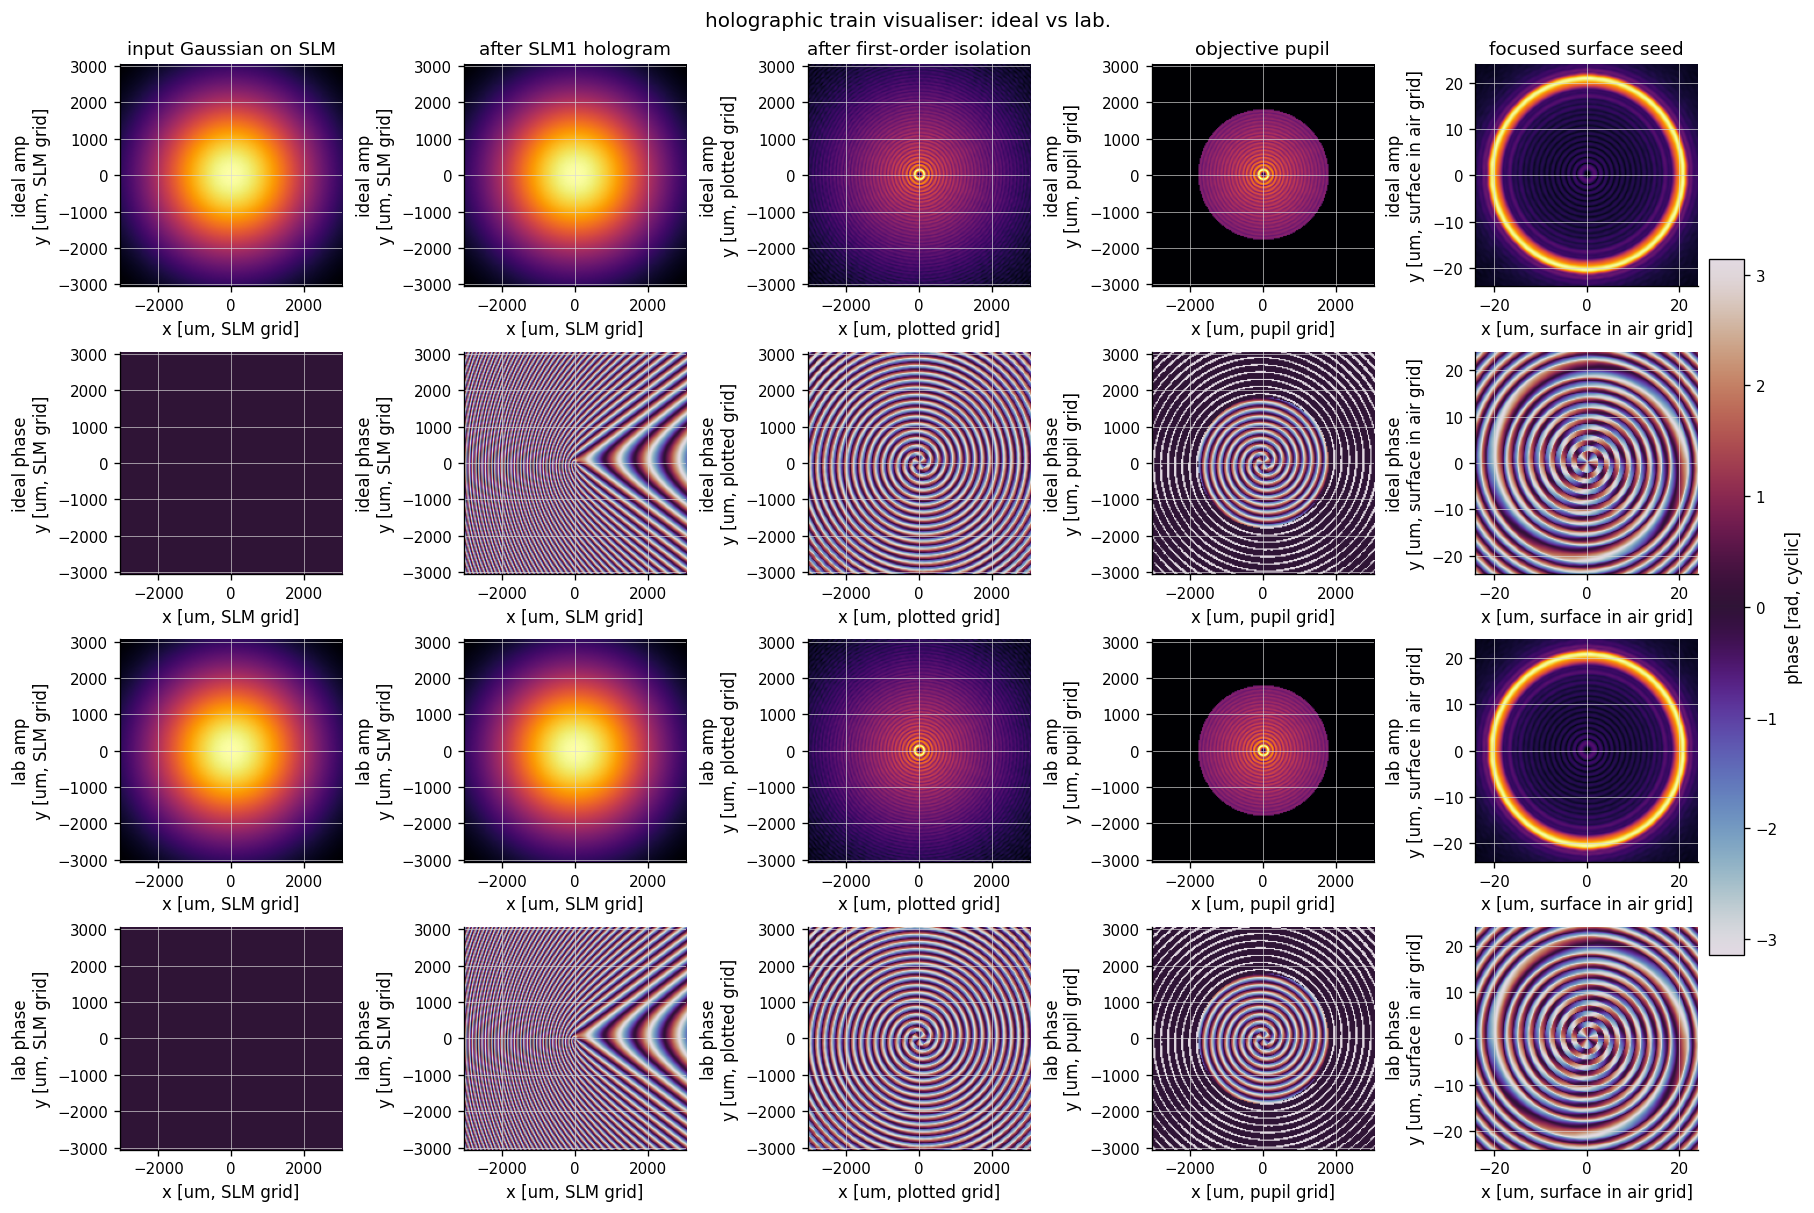

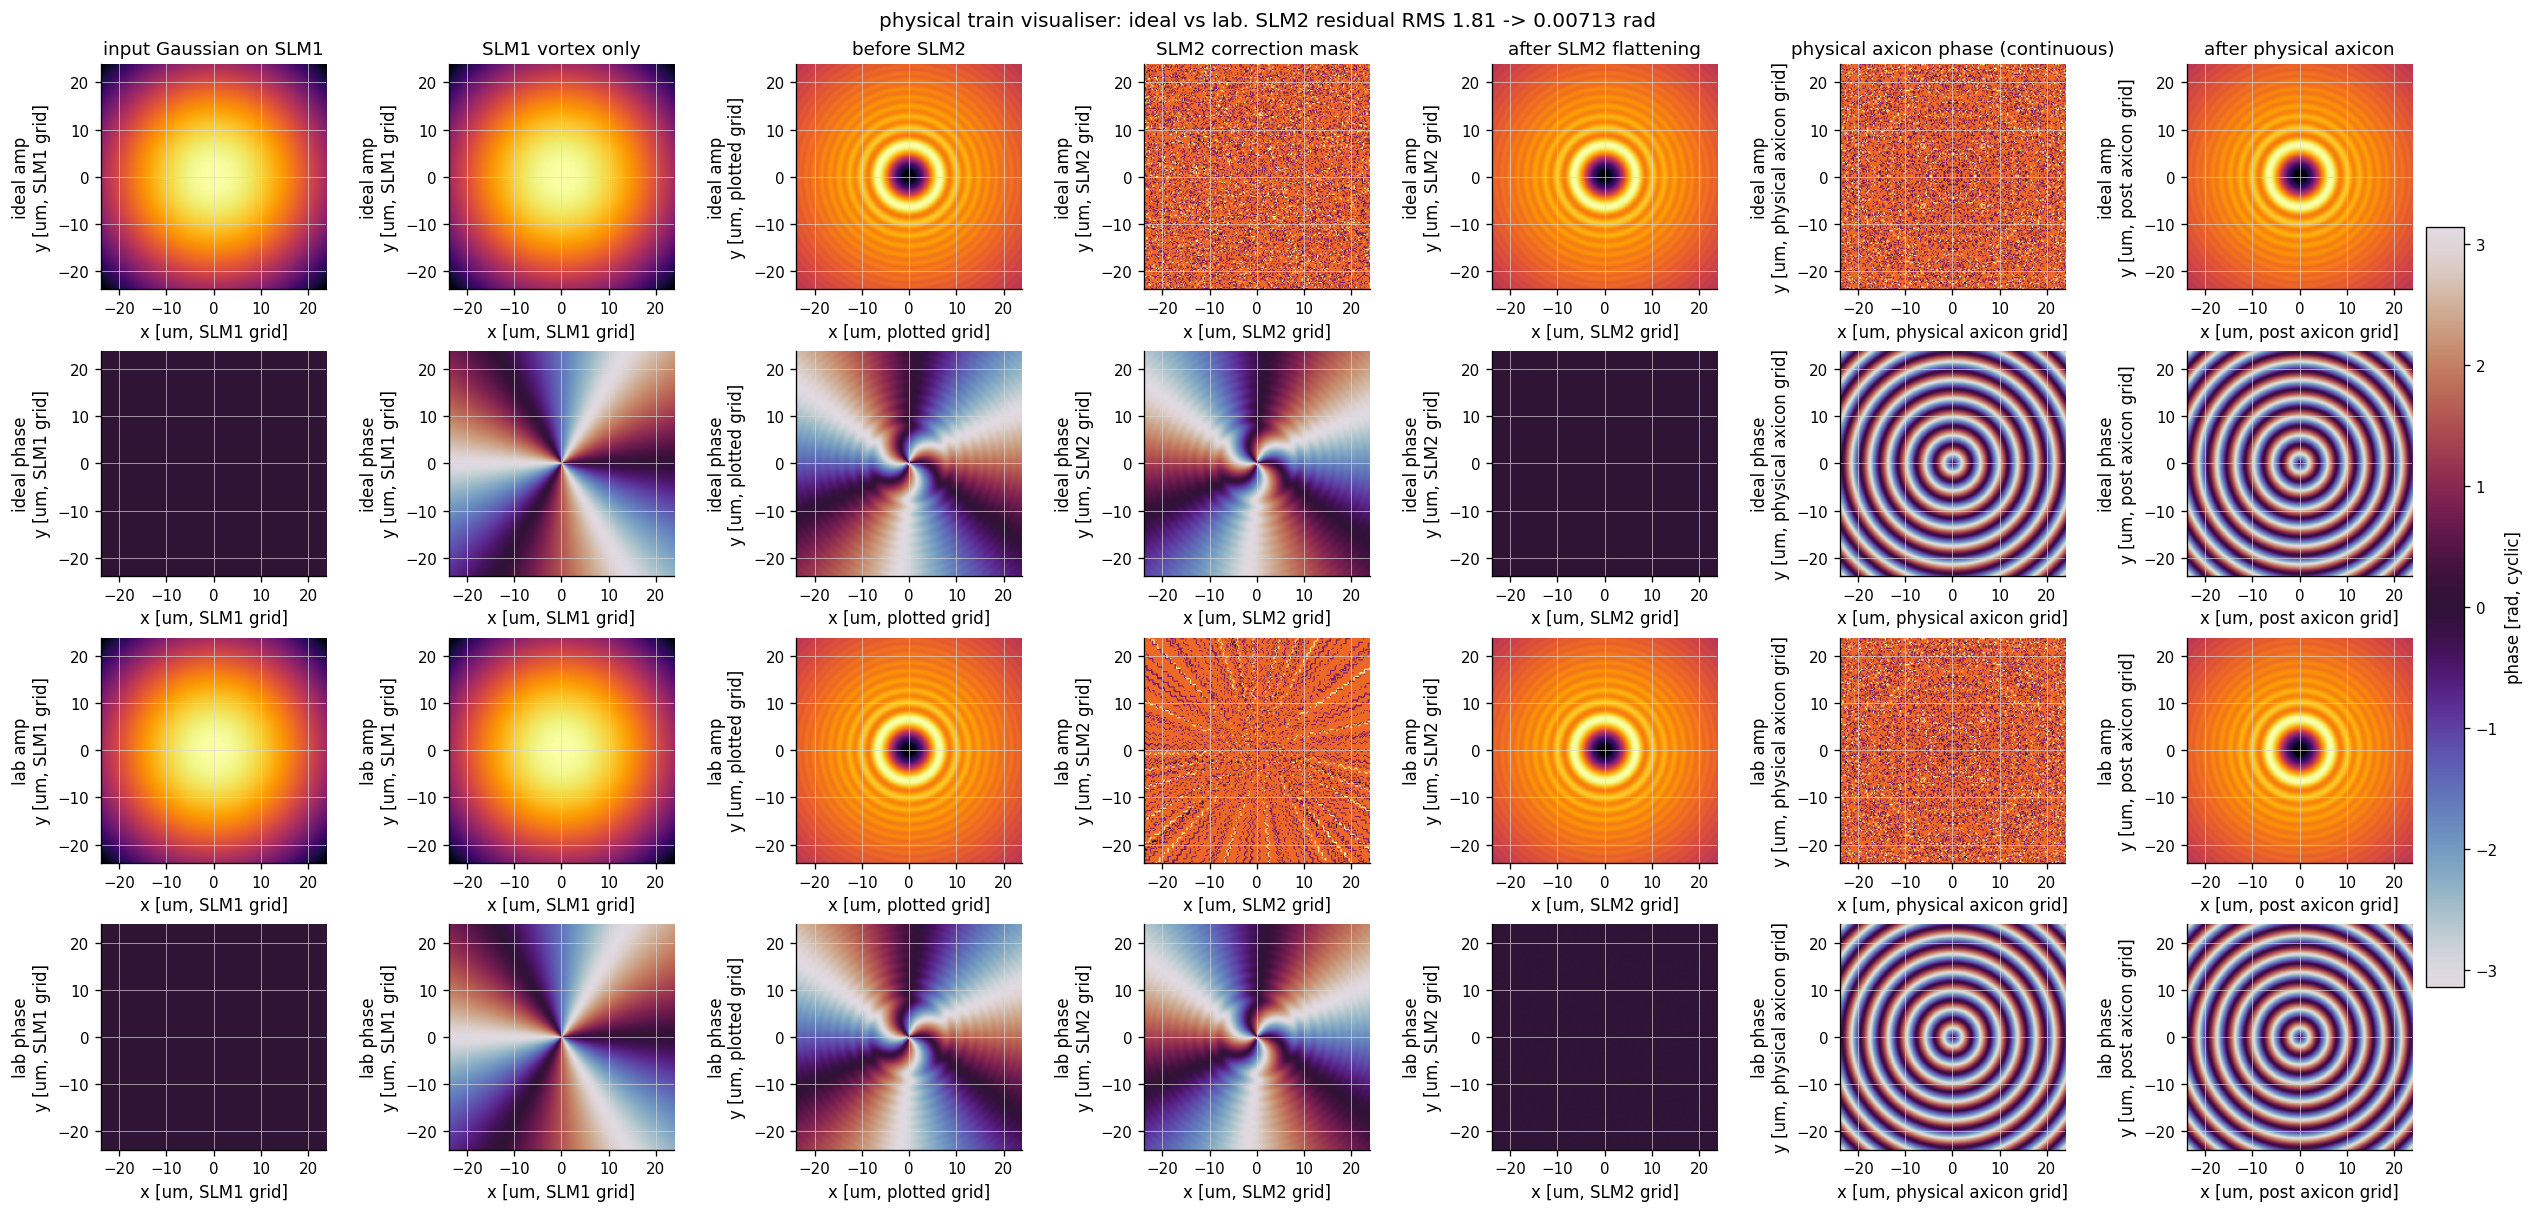

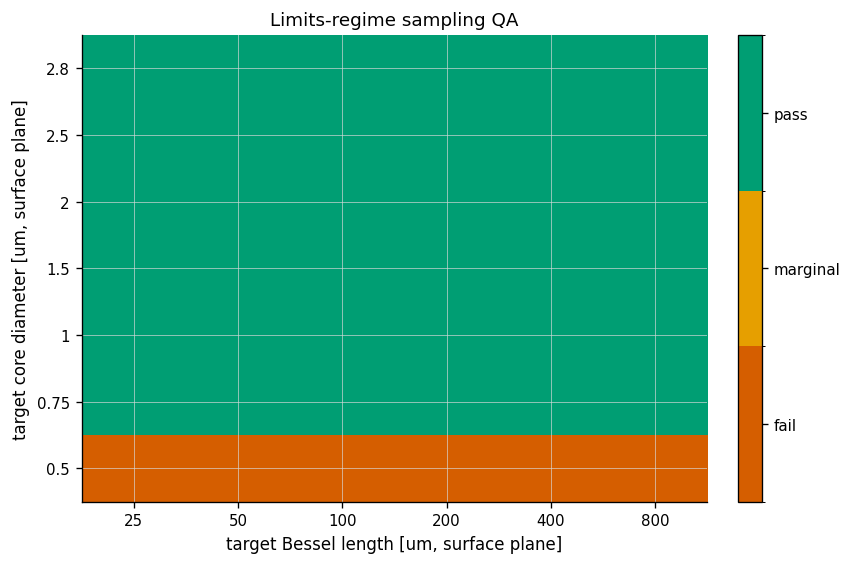

In [3]:
# Matched visual outputs generated by the shared Stage-C visualiser.
vbb_train_viz.plot_train_visualiser(base, method='holographic', output_dir=out_fig)
vbb_train_viz.plot_train_visualiser(base, method='physical', output_dir=out_fig)
vbb_train_viz.plot_sampling_qa(base, output_dir=out_fig)